# EXP007 RMSE by Step: DQN (normal) vs MFI

`EXP007/results/summary_uncor_1_DQN_normal_gamma_0.1.csv` と `EXP007/results/summary_uncor_1_MFI.csv` を読み込み、横軸を step、縦軸を RMSE として重ねてプロットする。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "EXP007" / "results").exists():
            return path
    raise FileNotFoundError("Could not find project root containing EXP007/results")


ROOT = find_project_root(Path.cwd())
RESULTS_DIR = ROOT / "EXP007" / "results"

DQN_PATH = RESULTS_DIR / "summary_uncor_1_DQN_normal_gamma_0.1.csv"
MFI_PATH = RESULTS_DIR / "summary_uncor_1_MFI.csv"
FIG_PATH = RESULTS_DIR / "rmse_by_step_dqn_normal_mfi.png"

dqn = pd.read_csv(DQN_PATH)
mfi = pd.read_csv(MFI_PATH)

display(dqn.head())
display(mfi.head())

,step,Bias,RMSE,MAE
0,1.0,0.273371,1.315197,1.090350
1,2.0,0.264819,1.249405,0.993394
2,3.0,0.190859,1.052060,0.815383
3,4.0,0.031889,1.116916,0.829283
4,5.0,-0.001860,0.994844,0.727971


,step,Bias,RMSE,MAE,r
0,1,0.285759,1.311647,1.087396,0.458879
1,2,0.252265,1.166601,0.932274,0.562766
2,3,0.173792,1.022323,0.798322,0.643177
3,4,0.011319,1.156760,0.837727,0.648158
4,5,0.108729,0.866848,0.670837,0.732334


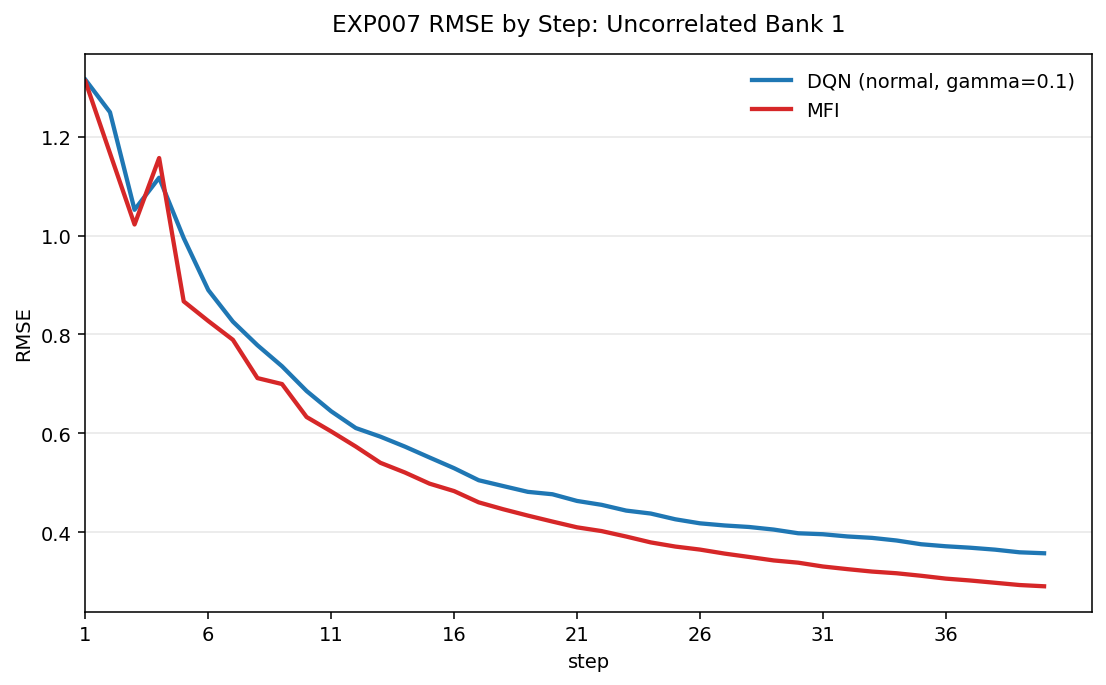

Saved figure to: /home/ituki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP007/results/rmse_by_step_dqn_normal_mfi.png


In [2]:
for frame in (dqn, mfi):
    frame["step"] = pd.to_numeric(frame["step"])
    frame["RMSE"] = pd.to_numeric(frame["RMSE"])

fig, ax = plt.subplots(figsize=(8, 5), dpi=140)

ax.plot(
    dqn["step"],
    dqn["RMSE"],
    label="DQN (normal, gamma=0.1)",
    linewidth=2.2,
    color="#1f77b4",
)
ax.plot(
    mfi["step"],
    mfi["RMSE"],
    label="MFI",
    linewidth=2.2,
    color="#d62728",
)

ax.set_title("EXP007 RMSE by Step: Uncorrelated Bank 1", pad=12)
ax.set_xlabel("step")
ax.set_ylabel("RMSE")
ax.set_xlim(left=1)
ax.set_xticks(range(1, int(max(dqn["step"].max(), mfi["step"].max())) + 1, 5))
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_PATH, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {FIG_PATH}")